# Cookie Cats A/B Test — 이상치 기준별 민감도 분석

**목적:** 이상치 제거 기준에 따라 D7 리텐션 가설 검정 결과가 얼마나 변하는가?  
결론이 안정적(robust)이라면 기준에 무관하게 동일한 의사결정을 내릴 수 있다.

| 기준 | 상한 | 제거 방식 |
|---|---|---|
| **통계적 P99** | ~499 라운드 | 상위 1% 극단치 제거 |
| **통계적 P99.5** | ~634 라운드 | 상위 0.5% 극단치 제거 |
| **도메인 기반** | 1,120 라운드 | 1라운드 180초 × 14일 × 하루 4시간 플레이 상한 |

> 세 기준 모두 **0라운드 유저(미실행)는 공통 제거**한다.

## 1. 환경 설정 및 데이터 로드

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib import font_manager as fm
from scipy import stats

# 한글 폰트 자동 탐지
preferred_fonts = [
    'AppleGothic', 'Malgun Gothic', 'NanumGothic',
    'Noto Sans CJK KR', 'Arial Unicode MS',
]
available_fonts = {f.name for f in fm.fontManager.ttflist}
font = next((name for name in preferred_fonts if name in available_fonts), 'DejaVu Sans')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.family'] = font
plt.rcParams['font.sans-serif'] = [font, 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
if font == 'DejaVu Sans':
    warnings.filterwarnings('ignore', message=r'Glyph .* missing from current font\.')

df_raw = pd.read_csv('../data/cookie_cats.csv')
# 공통 전처리: 0라운드 제거
df_base = df_raw[df_raw['sum_gamerounds'] > 0].copy()

print(f'원본           : {len(df_raw):,}명')
print(f'0라운드 제거 후: {len(df_base):,}명  (제거: {len(df_raw)-len(df_base):,}명)')
print(f'사용 폰트      : {font}')

원본           : 90,189명
0라운드 제거 후: 86,195명  (제거: 3,994명)
사용 폰트      : AppleGothic


## 2. 이상치 기준 정의

In [2]:
# --- 통계적 기준 ---
P99   = df_base['sum_gamerounds'].quantile(0.99)
P99_5 = df_base['sum_gamerounds'].quantile(0.995)

# --- 도메인 기반 기준 ---
# 1라운드 평균 소요시간 180초, 관찰 기간 14일, 하루 최대 합리적 플레이 4시간
SEC_PER_ROUND  = 180
OBS_DAYS       = 14
MAX_HOURS_DAY  = 4
DOMAIN_UPPER   = int(OBS_DAYS * MAX_HOURS_DAY * 3600 / SEC_PER_ROUND)   # 1,120라운드

thresholds = {
    'P99 (~499)'      : P99,
    'P99.5 (~634)'    : P99_5,
    f'도메인 ({DOMAIN_UPPER})' : DOMAIN_UPPER,
}

print('=== 이상치 기준 정의 ===')
print(f'P99   상한 : {P99:.1f} 라운드')
print(f'P99.5 상한 : {P99_5:.1f} 라운드')
print()
print(f'도메인 계산: {OBS_DAYS}일 × {MAX_HOURS_DAY}시간 × 3600초 / {SEC_PER_ROUND}초 = {DOMAIN_UPPER} 라운드')
print()
print('=== 기준별 분석 대상 유저 수 ===')
for name, cutoff in thresholds.items():
    n = (df_base['sum_gamerounds'] <= cutoff).sum()
    removed = len(df_base) - n
    print(f'{name:<20}: {n:>7,}명  (제거 {removed:,}명, {removed/len(df_base)*100:.2f}%)')

=== 이상치 기준 정의 ===
P99   상한 : 499.0 라운드
P99.5 상한 : 634.0 라운드

도메인 계산: 14일 × 4시간 × 3600초 / 180초 = 1120 라운드

=== 기준별 분석 대상 유저 수 ===
P99 (~499)          :  85,335명  (제거 860명, 1.00%)
P99.5 (~634)        :  85,764명  (제거 431명, 0.50%)
도메인 (1120)          :  86,120명  (제거 75명, 0.09%)


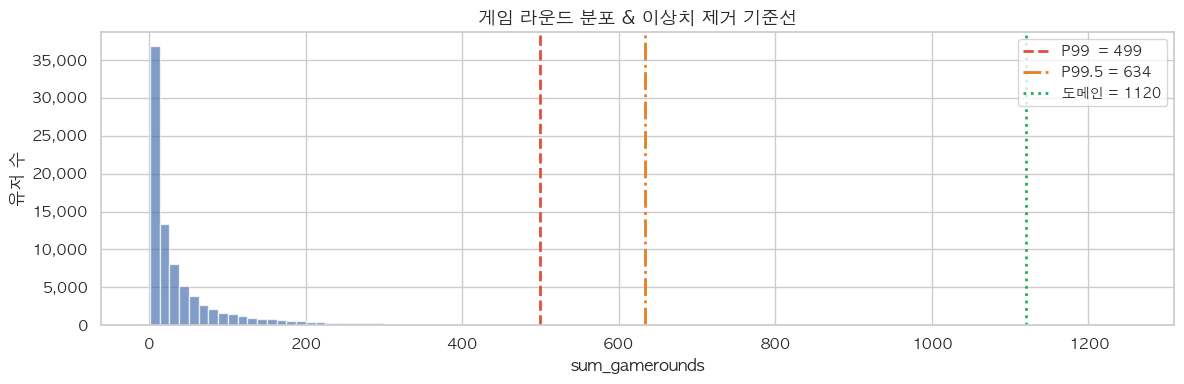

In [3]:
# sum_gamerounds 분포 + 기준선 시각화
p99_vis = df_base['sum_gamerounds'].quantile(0.99)
df_plot = df_base[df_base['sum_gamerounds'] <= p99_vis * 2.5]  # 시각화용 범위

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(df_plot['sum_gamerounds'], bins=100, color='#4C72B0', edgecolor='white', alpha=0.7)

line_styles = [
    (P99,          '#e74c3c', '--',  f'P99  = {P99:.0f}'),
    (P99_5,        '#e67e22', '-.',  f'P99.5 = {P99_5:.0f}'),
    (DOMAIN_UPPER, '#27ae60', ':',   f'도메인 = {DOMAIN_UPPER}'),
]
for val, color, ls, label in line_styles:
    ax.axvline(val, color=color, linewidth=2, linestyle=ls, label=label)

ax.set_xlabel('sum_gamerounds', fontsize=12)
ax.set_ylabel('유저 수', fontsize=12)
ax.set_title('게임 라운드 분포 & 이상치 제거 기준선', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 3. 검정 함수 정의

세 기준 모두 동일한 분석 파이프라인을 거친다:
**카이제곱 검정 → Two-proportion Z-test → Bootstrap**

In [4]:
def run_ab_tests(df: pd.DataFrame, label: str, n_boot: int = 5_000, seed: int = 42) -> dict:
    """gate_30 vs gate_40 D7 리텐션 가설 검정 (chi2 + z-test + bootstrap)"""
    g30 = df[df['version'] == 'gate_30']
    g40 = df[df['version'] == 'gate_40']

    n30, n40   = len(g30), len(g40)
    r30, r40   = g30['retention_7'].sum(), g40['retention_7'].sum()
    p30, p40   = r30 / n30, r40 / n40
    obs_diff   = p30 - p40

    # ── 카이제곱 ──────────────────────────────────────────────
    ct = np.array([[r30, n30 - r30], [r40, n40 - r40]])
    chi2_stat, p_chi2, _, _ = stats.chi2_contingency(ct)

    # ── Two-proportion Z-test ─────────────────────────────────
    p_pool    = (r30 + r40) / (n30 + n40)
    se_pool   = np.sqrt(p_pool * (1 - p_pool) * (1/n30 + 1/n40))
    z_stat    = obs_diff / se_pool
    p_z       = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    z_crit    = stats.norm.ppf(0.975)
    se_diff   = np.sqrt(p30*(1-p30)/n30 + p40*(1-p40)/n40)
    ci_z_lo   = obs_diff - z_crit * se_diff
    ci_z_hi   = obs_diff + z_crit * se_diff

    # ── Bootstrap ─────────────────────────────────────────────
    np.random.seed(seed)
    a30 = g30['retention_7'].values.astype(int)
    a40 = g40['retention_7'].values.astype(int)
    boot = np.array([
        np.random.choice(a30, len(a30), replace=True).mean() -
        np.random.choice(a40, len(a40), replace=True).mean()
        for _ in range(n_boot)
    ])
    ci_b_lo, ci_b_hi = np.percentile(boot, [2.5, 97.5])
    boot_null = boot - boot.mean()
    p_boot    = np.mean(np.abs(boot_null) >= np.abs(obs_diff))

    return {
        'label'     : label,
        'n'         : len(df),
        'n30'       : n30, 'n40': n40,
        'p30'       : p30, 'p40': p40,
        'obs_diff'  : obs_diff,
        'chi2'      : chi2_stat, 'p_chi2': p_chi2,
        'z'         : z_stat,    'p_z'   : p_z,
        'ci_z_lo'   : ci_z_lo,   'ci_z_hi': ci_z_hi,
        'p_boot'    : p_boot,
        'ci_b_lo'   : ci_b_lo,   'ci_b_hi': ci_b_hi,
        'boot_diffs': boot,
    }

print('검정 함수 정의 완료')

검정 함수 정의 완료


## 4. 기준별 분석 실행

In [5]:
results = {}
for name, cutoff in thresholds.items():
    df_cut = df_base[df_base['sum_gamerounds'] <= cutoff].copy()
    results[name] = run_ab_tests(df_cut, label=name)
    print(f'[{name}] 완료  (n={len(df_cut):,}명)')

[P99 (~499)] 완료  (n=85,335명)
[P99.5 (~634)] 완료  (n=85,764명)
[도메인 (1120)] 완료  (n=86,120명)


In [6]:
# 각 기준별 상세 결과 출력
ALPHA = 0.05

for name, r in results.items():
    print(f"{'='*60}")
    print(f"[{name}]  분석 대상: {r['n']:,}명")
    print(f"  gate_30: {r['p30']*100:.4f}%  ({r['n30']:,}명)")
    print(f"  gate_40: {r['p40']*100:.4f}%  ({r['n40']:,}명)")
    print(f"  관찰 차이 (p30-p40): {r['obs_diff']*100:+.4f}%p")
    print()
    print(f"  카이제곱   chi2={r['chi2']:.4f}  p={r['p_chi2']:.6f}  {'-> H0 기각' if r['p_chi2']<ALPHA else '-> H0 채택'}")
    print(f"  Z-test     Z={r['z']:.4f}      p={r['p_z']:.6f}  {'-> H0 기각' if r['p_z']<ALPHA else '-> H0 채택'}")
    print(f"             95% CI: [{r['ci_z_lo']*100:.4f}%p, {r['ci_z_hi']*100:.4f}%p]")
    print(f"  Bootstrap  p={r['p_boot']:.4f}              {'-> H0 기각' if r['p_boot']<ALPHA else '-> H0 채택'}")
    print(f"             95% CI: [{r['ci_b_lo']*100:.4f}%p, {r['ci_b_hi']*100:.4f}%p]")
print('='*60)

[P99 (~499)]  분석 대상: 85,335명
  gate_30: 19.0859%  (42,335명)
  gate_40: 18.2558%  (43,000명)
  관찰 차이 (p30-p40): +0.8300%p

  카이제곱   chi2=9.6259  p=0.001919  -> H0 기각
  Z-test     Z=3.1113      p=0.001862  -> H0 기각
             95% CI: [0.3071%p, 1.3530%p]
  Bootstrap  p=0.0014              -> H0 기각
             95% CI: [0.3149%p, 1.3691%p]
[P99.5 (~634)]  분석 대상: 85,764명
  gate_30: 19.4840%  (42,558명)
  gate_40: 18.6201%  (43,206명)
  관찰 차이 (p30-p40): +0.8639%p

  카이제곱   chi2=10.3207  p=0.001315  -> H0 기각
  Z-test     Z=3.2213      p=0.001276  -> H0 기각
             95% CI: [0.3382%p, 1.3896%p]
  Bootstrap  p=0.0002              -> H0 기각
             95% CI: [0.3438%p, 1.3895%p]
[도메인 (1120)]  분석 대상: 86,120명
  gate_30: 19.7767%  (42,727명)
  gate_40: 18.9616%  (43,393명)
  관찰 차이 (p30-p40): +0.8151%p

  카이제곱   chi2=9.1084  p=0.002544  -> H0 기각
  Z-test     Z=3.0266      p=0.002473  -> H0 기각
             95% CI: [0.2872%p, 1.3430%p]
  Bootstrap  p=0.0016              -> H0 기각
             95% CI

## 5. 시각화 — 기준별 Bootstrap 분포 비교

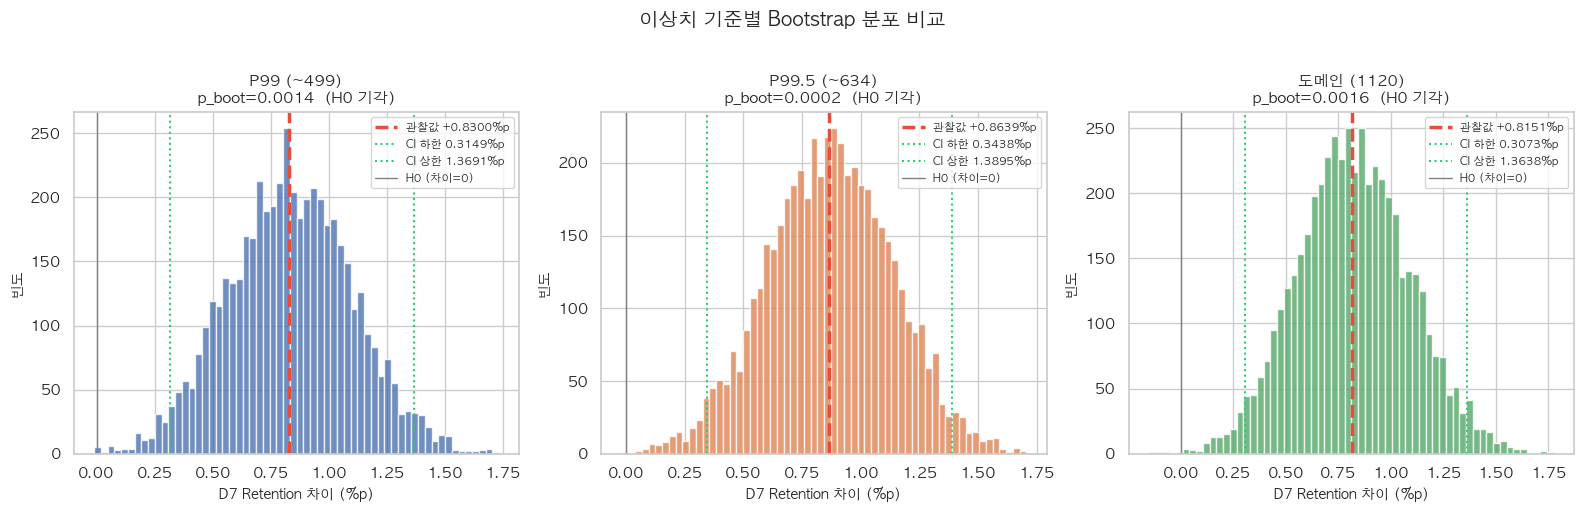

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
colors = ['#4C72B0', '#DD8452', '#55a868']

for ax, (name, r), color in zip(axes, results.items(), colors):
    ax.hist(r['boot_diffs'] * 100, bins=60, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(r['obs_diff']  * 100, color='#e74c3c',  linewidth=2.5, linestyle='--',
               label=f"관찰값 {r['obs_diff']*100:+.4f}%p")
    ax.axvline(r['ci_b_lo']   * 100, color='#2ecc71',  linewidth=1.5, linestyle=':',
               label=f"CI 하한 {r['ci_b_lo']*100:.4f}%p")
    ax.axvline(r['ci_b_hi']   * 100, color='#2ecc71',  linewidth=1.5, linestyle=':',
               label=f"CI 상한 {r['ci_b_hi']*100:.4f}%p")
    ax.axvline(0, color='grey', linewidth=1, linestyle='-', label='H0 (차이=0)')

    verdict = 'H0 기각' if r['p_boot'] < ALPHA else 'H0 채택'
    ax.set_title(f'{name}\np_boot={r["p_boot"]:.4f}  ({verdict})', fontsize=11, fontweight='bold')
    ax.set_xlabel('D7 Retention 차이 (%p)', fontsize=10)
    ax.set_ylabel('빈도', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('이상치 기준별 Bootstrap 분포 비교', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. 종합 비교표 & 결론

In [8]:
rows = []
for name, r in results.items():
    rows.append({
        '기준'                  : name,
        '분석 n'               : f"{r['n']:,}",
        'gate_30 D7 (%)'       : f"{r['p30']*100:.4f}",
        'gate_40 D7 (%)'       : f"{r['p40']*100:.4f}",
        '차이 (%p)'            : f"{r['obs_diff']*100:+.4f}",
        'chi2 p'               : f"{r['p_chi2']:.4f}",
        'Z-test p'             : f"{r['p_z']:.4f}",
        'Z 95% CI'             : f"[{r['ci_z_lo']*100:.3f}, {r['ci_z_hi']*100:.3f}]",
        'Bootstrap p'          : f"{r['p_boot']:.4f}",
        'Boot 95% CI'          : f"[{r['ci_b_lo']*100:.3f}, {r['ci_b_hi']*100:.3f}]",
        'H0 기각 (모두)'       : '기각' if all([
                                    r['p_chi2'] < ALPHA,
                                    r['p_z']    < ALPHA,
                                    r['p_boot'] < ALPHA
                                ]) else '채택/불일치',
    })

summary_df = pd.DataFrame(rows)
print('=== 이상치 기준별 검정 결과 종합 ===')
print(summary_df.to_string(index=False))

=== 이상치 기준별 검정 결과 종합 ===
          기준   분석 n gate_30 D7 (%) gate_40 D7 (%) 차이 (%p) chi2 p Z-test p       Z 95% CI Bootstrap p    Boot 95% CI H0 기각 (모두)
  P99 (~499) 85,335        19.0859        18.2558 +0.8300 0.0019   0.0019 [0.307, 1.353]      0.0014 [0.315, 1.369]         기각
P99.5 (~634) 85,764        19.4840        18.6201 +0.8639 0.0013   0.0013 [0.338, 1.390]      0.0002 [0.344, 1.390]         기각
  도메인 (1120) 86,120        19.7767        18.9616 +0.8151 0.0025   0.0025 [0.287, 1.343]      0.0016 [0.307, 1.364]         기각


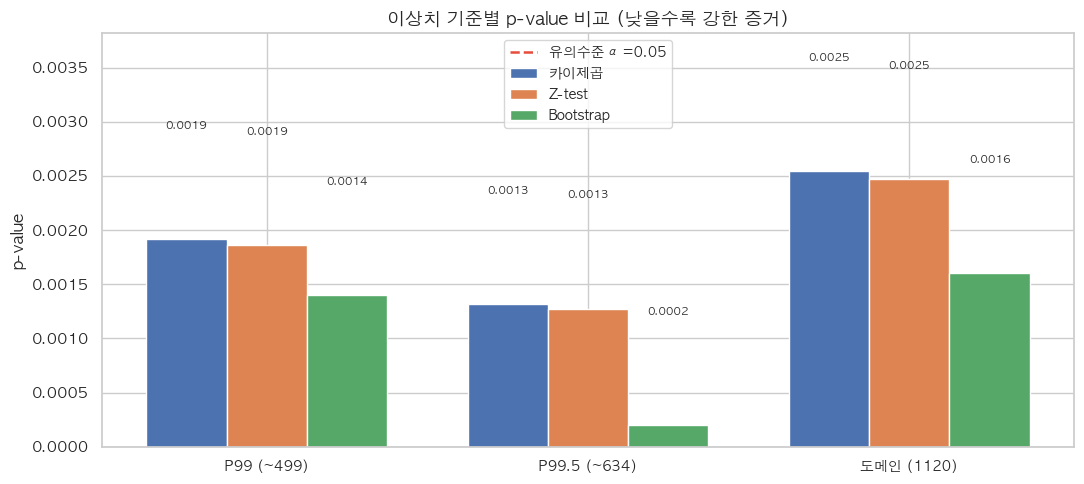

In [9]:
# p-value 비교 시각화
names    = list(results.keys())
p_chi2s  = [results[n]['p_chi2'] for n in names]
p_zs     = [results[n]['p_z']    for n in names]
p_boots  = [results[n]['p_boot'] for n in names]

x = np.arange(len(names))
w = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w,  p_chi2s, w, label='카이제곱',    color='#4C72B0', edgecolor='white')
ax.bar(x,      p_zs,    w, label='Z-test',      color='#DD8452', edgecolor='white')
ax.bar(x + w,  p_boots, w, label='Bootstrap',   color='#55a868', edgecolor='white')
ax.axhline(ALPHA, color='#e74c3c', linewidth=1.8, linestyle='--', label=f'유의수준 α={ALPHA}')

for i, (pc, pz, pb) in enumerate(zip(p_chi2s, p_zs, p_boots)):
    for j, (xpos, val) in enumerate([(i-w, pc), (i, pz), (i+w, pb)]):
        ax.text(xpos, val + 0.001, f'{val:.4f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=10)
ax.set_ylabel('p-value', fontsize=12)
ax.set_title('이상치 기준별 p-value 비교 (낮을수록 강한 증거)', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(p_chi2s + p_zs + p_boots) * 1.5)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

/var/folders/y7/w247tcfd5q3bmlq5v2hz_thw0000gn/T/ipykernel_61013/2488894241.py:20: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/home1/Documents/cookie_cats/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


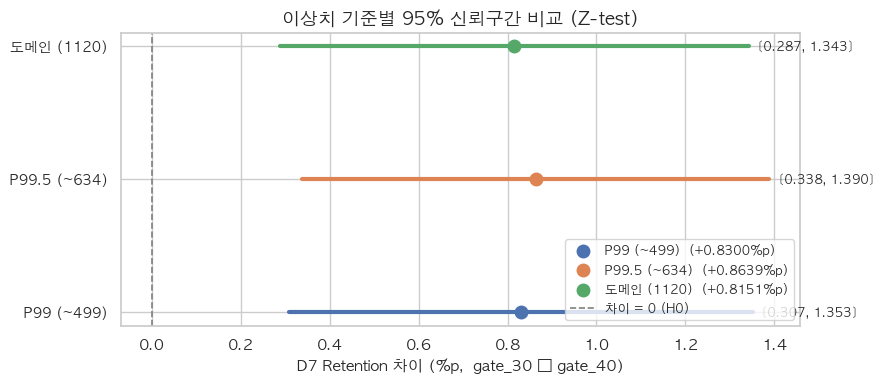

In [10]:
# 95% CI 비교 시각화 (Z-test 기준)
fig, ax = plt.subplots(figsize=(9, 4))

colors_ci = ['#4C72B0', '#DD8452', '#55a868']
for i, (name, r) in enumerate(results.items()):
    mid  = r['obs_diff'] * 100
    lo   = r['ci_z_lo']  * 100
    hi   = r['ci_z_hi']  * 100
    ax.plot([lo, hi], [i, i], color=colors_ci[i], linewidth=3, solid_capstyle='round')
    ax.plot(mid, i, 'o', color=colors_ci[i], markersize=9, zorder=5,
            label=f'{name}  ({mid:+.4f}%p)')
    ax.text(hi + 0.01, i, f' [{lo:.3f}, {hi:.3f}]', va='center', fontsize=9)

ax.axvline(0, color='grey', linewidth=1.2, linestyle='--', label='차이 = 0 (H0)')
ax.set_yticks(range(len(results)))
ax.set_yticklabels(list(results.keys()), fontsize=10)
ax.set_xlabel('D7 Retention 차이 (%p,  gate_30 − gate_40)', fontsize=11)
ax.set_title('이상치 기준별 95% 신뢰구간 비교 (Z-test)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

In [11]:
# 최종 결론
print('=== 민감도 분석 결론 ===')
print()
all_reject = all(
    r['p_chi2'] < ALPHA and r['p_z'] < ALPHA and r['p_boot'] < ALPHA
    for r in results.values()
)

if all_reject:
    print('세 가지 이상치 기준 × 세 가지 검정 방법 (총 9개 검정) 모두 H0 기각.')
    print()
    print('결론: gate_30의 D7 리텐션이 gate_40보다 일관되게 높다.')
    print('      이 결과는 이상치 제거 기준에 무관하게 안정적(robust)이다.')
    print()
    diffs = [r['obs_diff']*100 for r in results.values()]
    print(f'차이 범위: {min(diffs):+.4f}%p ~ {max(diffs):+.4f}%p')
    print()
    print('비즈니스 권고: Gate를 레벨 30으로 유지한다.')
else:
    print('일부 기준/검정에서 결론이 다름 — 개별 결과를 검토할 것')
    for name, r in results.items():
        reject = r['p_chi2'] < ALPHA and r['p_z'] < ALPHA and r['p_boot'] < ALPHA
        print(f'  {name}: {"H0 기각" if reject else "H0 채택/불일치"}')

=== 민감도 분석 결론 ===

세 가지 이상치 기준 × 세 가지 검정 방법 (총 9개 검정) 모두 H0 기각.

결론: gate_30의 D7 리텐션이 gate_40보다 일관되게 높다.
      이 결과는 이상치 제거 기준에 무관하게 안정적(robust)이다.

차이 범위: +0.8151%p ~ +0.8639%p

비즈니스 권고: Gate를 레벨 30으로 유지한다.


---

## 7. 부록: Full ITT 검증 — 0라운드 유저 포함

**목적:** 본 분석은 0라운드 유저(앱 설치 후 미실행, 3,994명)를 제외했다.  
이들은 Gate를 경험할 수 없으므로 제외가 합리적이지만, 엄격한 ITT 원칙에서는 무작위 배정된 모든 유저를 포함해야 한다.  
0라운드 포함 시에도 결론이 동일한지 확인한다.

| 전처리 | 상한 | 대상 수 |
|--------|------|:------:|
| 기본 분석 (0라운드 제거) | 30,000 | 86,194명 |
| **Full ITT (0라운드 포함)** | 30,000 | **86,188명** ※ |

> ※ 극단 이상치(sum_gamerounds > 30,000, 1명)만 제거. 0라운드 유저 3,994명 포함.

In [12]:
# Full ITT: 0라운드 포함, 극단 이상치(>30,000)만 제거
df_full_itt = df_raw[df_raw['sum_gamerounds'] <= 30_000].copy()

r_full = run_ab_tests(df_full_itt, label='Full ITT (0라운드 포함)', seed=42)

# 기본 분석 기준 (0라운드 제거 + 30,000 상한) — 비교 기준
df_base_orig = df_raw[(df_raw['sum_gamerounds'] > 0) &
                      (df_raw['sum_gamerounds'] <= 30_000)].copy()
r_base = run_ab_tests(df_base_orig, label='기본 분석 (0라운드 제거)', seed=42)

# ── 비교 출력 ──────────────────────────────────────────────────────────
print('=' * 65)
print('  Full ITT vs 기본 분석 비교 (D7 잔존율)')
print('=' * 65)
compare_rows = []
for r in [r_base, r_full]:
    compare_rows.append({
        '분석'             : r['label'],
        'n'               : f"{r['n']:,}",
        'gate_30 D7 (%)'  : f"{r['p30']*100:.4f}",
        'gate_40 D7 (%)'  : f"{r['p40']*100:.4f}",
        '차이 (%p)'       : f"{r['obs_diff']*100:+.4f}",
        'chi2 p'          : f"{r['p_chi2']:.4f}",
        'Z-test p'        : f"{r['p_z']:.4f}",
        'Boot 95% CI'     : f"[{r['ci_b_lo']*100:.3f}, {r['ci_b_hi']*100:.3f}]",
        'H0 기각'         : '기각' if r['p_chi2'] < ALPHA else '채택',
    })

cmp_df = pd.DataFrame(compare_rows)
print(cmp_df.to_string(index=False))

# ── 해석 ───────────────────────────────────────────────────────────────
print()
print('=== 해석 ===')
if r_full['p_chi2'] < ALPHA:
    print(f'Full ITT  p_chi2={r_full["p_chi2"]:.4f} < 0.05  →  H0 기각')
    print(f'0라운드 유저 3,994명을 포함해도 결론이 동일하다.')
    print(f'차이: {r_full["obs_diff"]*100:+.4f}%p  '
          f'(기본 분석 대비 {(r_full["obs_diff"] - r_base["obs_diff"])*100:+.4f}%p 변화)')
    print()
    print('→ "gate_30 유지" 권고는 0라운드 전처리 기준에도 무관하게 안정적이다.')
else:
    print(f'Full ITT  p={r_full["p_chi2"]:.4f} ≥ 0.05  →  H0 채택 (결론 변화 있음 — 재검토 필요)')

  Full ITT vs 기본 분석 비교 (D7 잔존율)
                분석      n gate_30 D7 (%) gate_40 D7 (%) 차이 (%p) chi2 p Z-test p    Boot 95% CI H0 기각
   기본 분석 (0라운드 제거) 86,194        19.8424        19.0321 +0.8103 0.0027   0.0026 [0.270, 1.357]    기각
Full ITT (0라운드 포함) 90,188        19.0183        18.2000 +0.8183 0.0016   0.0016 [0.318, 1.314]    기각

=== 해석 ===
Full ITT  p_chi2=0.0016 < 0.05  →  H0 기각
0라운드 유저 3,994명을 포함해도 결론이 동일하다.
차이: +0.8183%p  (기본 분석 대비 +0.0080%p 변화)

→ "gate_30 유지" 권고는 0라운드 전처리 기준에도 무관하게 안정적이다.
